In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# 1st step is to define a class for mantaining the State
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float

In [11]:
# define your graph
graph = StateGraph(BMIState)

def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height**2)

    state['bmi'] = round(bmi,2)

    return state

def check_fitness(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 < bmi <= 25 :
        state['category'] = 'Normal'
    elif 25 < bmi < 30 :
        state['category'] = 'Overweight'
    else:
        state['category'] = 'obese'

    return state

# add nodes to your graph
graph.add_node("calculate_bmi" , calculate_bmi)
graph.add_node("check_fitness", check_fitness)
# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'check_fitness')
graph.add_edge('check_fitness', END)

# compile the graph

workflow = graph.compile()




In [12]:
initial_state = {'weight_kg': 65, 'height_m': 1.73}

result = workflow.invoke(initial_state)

In [13]:
print(result)

{'height_m': 1.73, 'weight_kg': 65, 'bmi': 21.72}


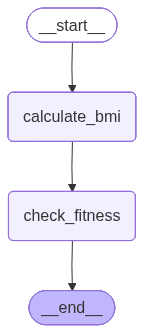

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())